<a href="https://colab.research.google.com/github/hmbholamajhi-eng/Diabetes_Logistic_Regression/blob/main/Diabetes_Prediction_Logistic_Regression_Bhola_Sankar_Majhi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#  DIABETES LOGISTIC REGRESSION PROJECT REPORT

**Project:** Diabetes Prediction using Kaggle Data

**Student:** BHOLA SANKAR MAJHI

**Date:** 03/10/2026

**Kaggle Dataset Link:**  
https://www.kaggle.com/datasets/hasibur013/diabetes-dataset?resource=download


# Diabetes Prediction using Logistic Regression

## Objective
The objective of this project is to predict whether a patient has diabetes or not using **Logistic Regression**. We use the `Outcome` column as the target:

- `Outcome = 0` means **No Diabetes**
- `Outcome = 1` means **Diabetes**

## Dataset Introduction
The dataset has 768 rows (patients) and 9 columns. The input columns are `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction` and `Age`. The last column `Outcome` is the target.

## Steps followed in this notebook
Import libraries, load data, check missing values and duplicates, EDA (univariate, bivariate, correlation), preprocessing, outlier check using IQR, train-test split, SMOTE on training data, StandardScaler, Logistic Regression, prediction, accuracy, classification report, confusion matrix and final conclusion.

**Note:** This is an educational machine learning project. It is not a medical diagnosis system.

## 1. Import Libraries and Load Dataset

In [56]:
import pandas as pd # Import the pandas library for data manipulation and analysis.
import numpy as np # Import the numpy library for numerical operations.
import matplotlib.pyplot as plt # Import the matplotlib.pyplot module for creating static, interactive, and animated visualizations.
import seaborn as sns # Import the seaborn library for statistical data visualization, built on matplotlib.

sns.set_theme(style='whitegrid') # Set the aesthetic style of the plots to 'whitegrid' for better readability.

In [57]:
# Choose the diabetes CSV file from your computer
from google.colab import files # Import the 'files' module from google.colab to handle file uploads in Colab.

uploaded = files.upload() # Prompt the user to upload a file and store the uploaded file information.
csv_file = next(iter(uploaded)) # Get the filename of the first uploaded file.
df = pd.read_csv(csv_file) # Read the CSV file into a pandas DataFrame named 'df'.

print('Shape:', df.shape) # Print the shape (number of rows and columns) of the DataFrame.
df.head() # Display the first 5 rows of the DataFrame to get a quick overview of the data.

Saving diabetes_dataset.csv to diabetes_dataset (1).csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Observation (dataset loaded):**
- The dataset loaded properly and the shape is (768, 9), so there are 768 patients and 9 columns.
- In the first 5 rows we can already see that some values are `0`, for example Insulin is 0 in the first three rows and SkinThickness is 0 in the third row. We will check this properly later because these columns should not normally be zero.

## 2. Missing Values and Data Types

In [58]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Observation (missing values and info):**
- `df.isnull().sum()` shows 0 missing values in every column.
- `df.info()` shows all 9 columns have 768 non-null values. 7 columns are `int64` and 2 columns (`BMI`, `DiabetesPedigreeFunction`) are `float64`. There is no text/categorical column in the original data.
- But "no NaN values" does not mean the data is fully clean. Some columns contain `0` values that look like hidden missing values. We check this in the EDA part below.

## 3. Duplicate Check

In [60]:
df.duplicated().sum()

np.int64(0)

**Observation (duplicates):** `df.duplicated().sum()` gives 0, so there are no duplicate rows and nothing needs to be dropped.

## 4. Basic Dataset Inspection

In [61]:
df.shape

(768, 9)

In [62]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [63]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [64]:
df.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


**Observation (dataset inspection):**
- Shape is (768, 9) and the columns are the 8 input features plus `Outcome`.
- All columns are numeric (`int64` or `float64`).
- `nunique()` shows `Outcome` has only 2 unique values (0 and 1), so this is a binary classification problem. `Pregnancies` has 17 unique values, while `DiabetesPedigreeFunction` has 517 and `BMI` has 248, so these are more continuous.

## 5. Target Variable (Outcome) Distribution

In [65]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [66]:
df["Outcome"].value_counts(normalize=True) * 100


,proportion
Outcome,
0,65.104167
1,34.895833


In [67]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Pregnancies,0.0
Glucose,0.0
BloodPressure,0.0
SkinThickness,0.0
Insulin,0.0
BMI,0.0
DiabetesPedigreeFunction,0.0
Age,0.0
Outcome,0.0


**Observation (Outcome counts):**
- There are 500 patients with `Outcome = 0` (No Diabetes) which is 65.10%, and 268 patients with `Outcome = 1` (Diabetes) which is 34.90%.
- The percentage of missing values is 0.0 for every column (last cell), which matches the earlier check.
- The data is imbalanced because No Diabetes patients are almost double the Diabetes patients.

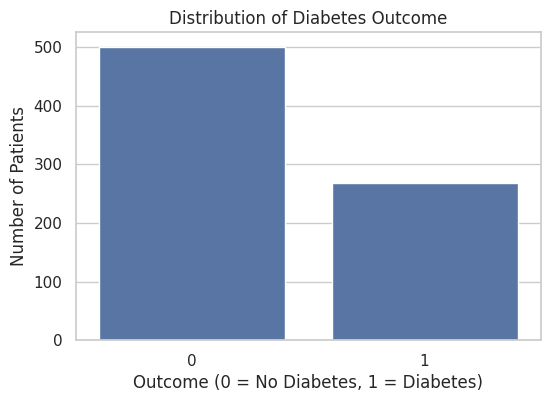

In [68]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Outcome', data=df)

plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Patients')

plt.show()

**Observation (Outcome countplot):** The bar for No Diabetes (500) is clearly taller than the bar for Diabetes (268). If a model just predicted "No Diabetes" for everyone it would already be correct about 65% of the time, so accuracy alone can be misleading here. This imbalance is the reason we use SMOTE on the training data later.

## 6. Univariate Analysis

We look at each numerical column one by one using `describe()` and histograms. The `Outcome` column is also numeric so it appears in these outputs too.

In [69]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [70]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Observation (describe):**
- `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` all have a minimum value of 0. A Glucose, BloodPressure or BMI of 0 is not possible for a living person, so these are most likely missing values stored as 0.
- `Insulin` has mean 79.80 and median 30.50, with a maximum of 846 and standard deviation of 115.24. The mean is much bigger than the median, so Insulin is skewed to the right.
- `Age` goes from 21 to 81 with median 29, so most patients are young and a few are much older.
- `Pregnancies` goes from 0 to 17 with median 3.

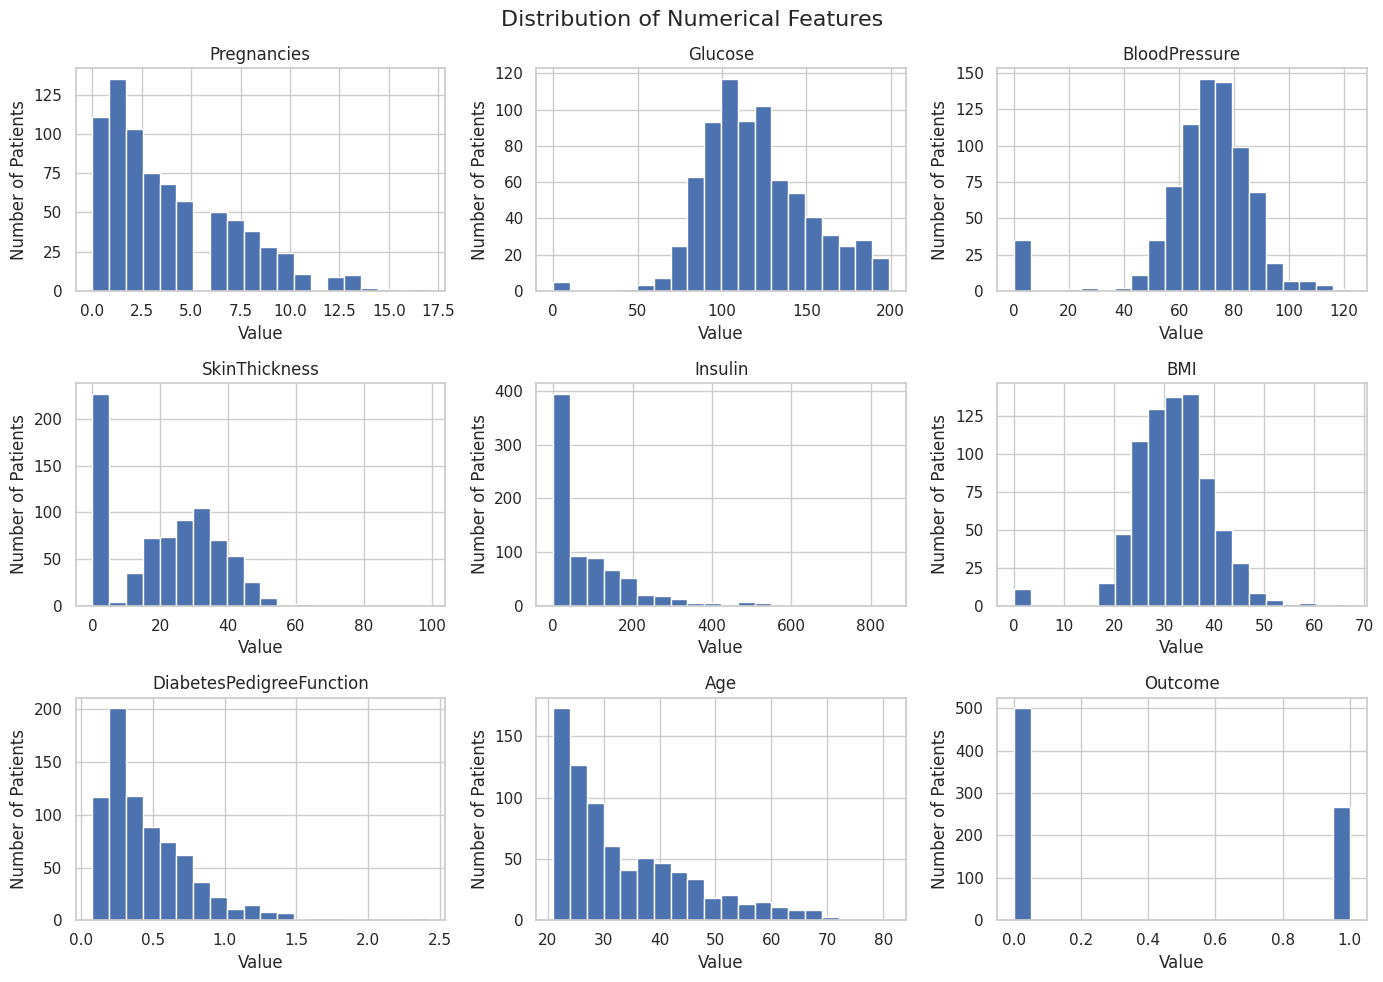

In [71]:
axes = df[numeric_cols].hist(figsize=(14, 10), bins=20)

for ax in axes.flatten():
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of Patients')

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()

plt.show()

**Observation (histograms):**
- `Glucose`, `BloodPressure` and `BMI` look roughly bell shaped, but each has a small separate bar at 0. These are the invalid zero values.
- `SkinThickness` and `Insulin` have a very big bar at 0 (many zeros). `Insulin` also has a long tail to the right.
- `Pregnancies`, `DiabetesPedigreeFunction` and `Age` are skewed to the right, most values are small and only a few are large.
- `Outcome` has just two bars (0 and 1) and the 0 bar is higher, which matches the earlier count.

## 7. Checking Zero Values

In [72]:
# Count how many zeros are present in each column
(df.drop('Outcome', axis=1) == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0


**Observation (zero values):**
- Zeros per column: Pregnancies 111, Glucose 5, BloodPressure 35, SkinThickness 227, Insulin 374, BMI 11. `DiabetesPedigreeFunction` and `Age` have no zeros.
- `Pregnancies = 0` is a valid value (a patient may have had no pregnancy), so we keep it as it is.
- Zeros in `Glucose`, `BloodPressure` and `BMI` are not possible in real life. Zeros in `SkinThickness` and `Insulin` most likely mean the value was not measured. Insulin has 374 zeros out of 768 rows (almost half), so this is a big issue.
- The graphs in the EDA part still use the original data (with zeros). We will treat these zeros in the preprocessing part, after the train-test split.

## 8. Bivariate Analysis
Now we compare the features with the target `Outcome`. First we use the EDA group columns with countplots, then boxplots and a scatter plot (these use the original data, zeros not yet treated).

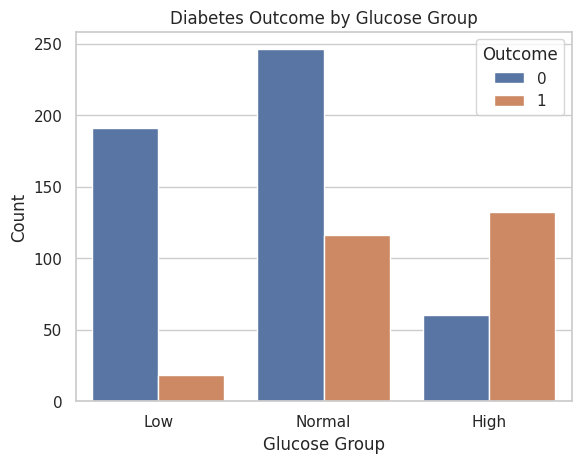

In [73]:
df['Glucose_Group'] = pd.cut(
    df['Glucose'],
    bins=[0, 100, 140, 200],
    labels=['Low', 'Normal', 'High']
)

sns.countplot(x='Glucose_Group', hue='Outcome', data=df)

plt.title('Diabetes Outcome by Glucose Group')
plt.xlabel('Glucose Group')
plt.ylabel('Count')

plt.show()

**Observation (Glucose group vs Outcome):**
The groups are `Low` (0 to 100), `Normal` (100 to 140) and `High` (140 to 200). These groups are made only for EDA.
- Low: 191 No Diabetes and 18 Diabetes (about 8.6% diabetes)
- Normal: 246 No Diabetes and 116 Diabetes (about 32.0% diabetes)
- High: 60 No Diabetes and 132 Diabetes (about 68.8% diabetes)

The share of diabetes patients goes up clearly as the glucose group goes up. The 5 patients with Glucose = 0 are not shown in this graph because 0 is outside the bins.

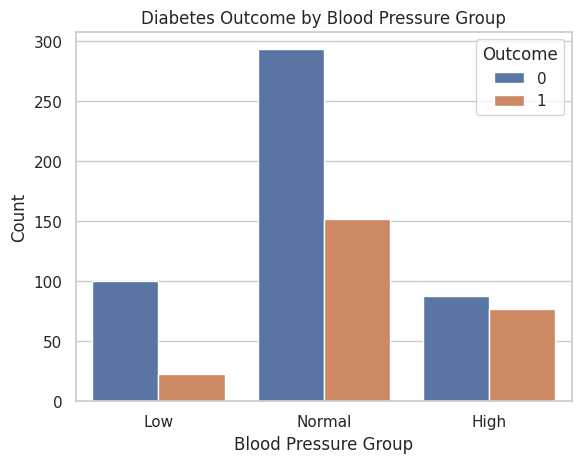

In [74]:
df['BloodPressure_Group'] = pd.cut(
    df['BloodPressure'],
    bins=[0, 60, 80, 130],
    labels=['Low', 'Normal', 'High']
)

sns.countplot(x='BloodPressure_Group', hue='Outcome', data=df)

plt.title('Diabetes Outcome by Blood Pressure Group')
plt.xlabel('Blood Pressure Group')
plt.ylabel('Count')

plt.show()

**Observation (BloodPressure group vs Outcome):**
The groups are `Low` (0 to 60), `Normal` (60 to 80) and `High` (80 to 130). These cut points are only for EDA.
- Low: 100 No Diabetes and 23 Diabetes (about 18.7% diabetes)
- Normal: 293 No Diabetes and 152 Diabetes (about 34.2% diabetes)
- High: 88 No Diabetes and 77 Diabetes (about 46.7% diabetes)

The diabetes share also increases with the blood pressure group, but the change is smaller than for glucose. The 35 patients with BloodPressure = 0 are not shown here.

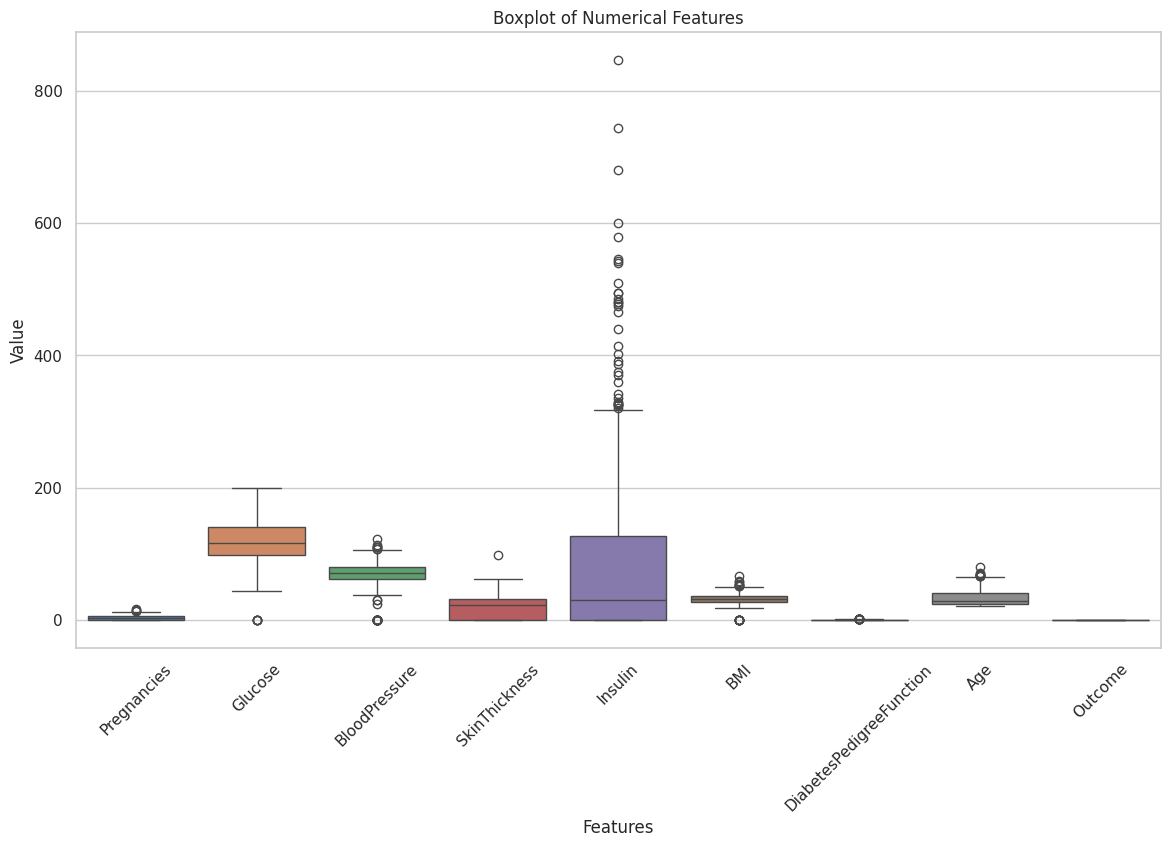

In [75]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[numeric_cols])

plt.title('Boxplot of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.xticks(rotation=45)

plt.show()

**Observation (boxplot of all features):**
- `Insulin` has the biggest range (up to 846) and many dots above the upper whisker, which are outliers.
- Because Insulin is so large, the boxes of small-scale columns like `DiabetesPedigreeFunction` and `Pregnancies` look very flat, so this graph is hard to read for them.
- `Glucose`, `BloodPressure` and `BMI` have dots at 0, which are the invalid zeros. `SkinThickness` has one dot near 100.

## 9. Correlation Analysis

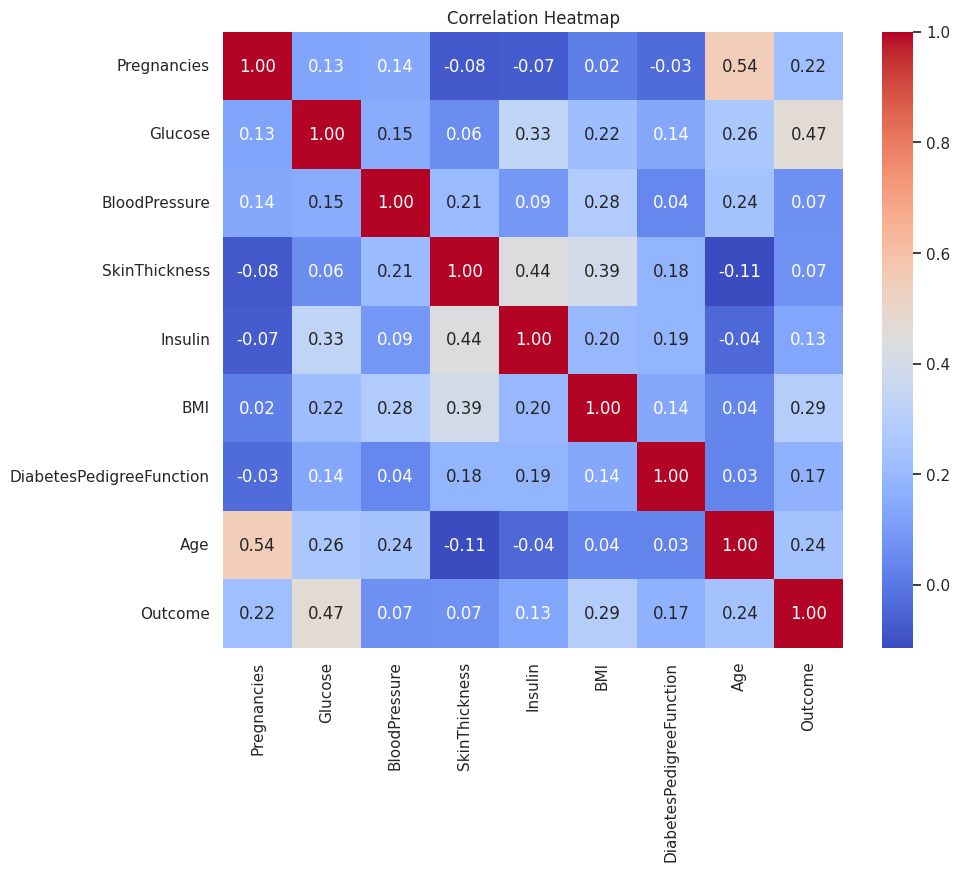

In [76]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

**Observation (correlation heatmap):**
- Correlation with `Outcome`: Glucose 0.47 (highest), BMI 0.29, Age 0.24, Pregnancies 0.22, DiabetesPedigreeFunction 0.17, Insulin 0.13, BloodPressure 0.07 and SkinThickness 0.07.
- Among the input features, the biggest correlations are Age and Pregnancies (0.54), Insulin and SkinThickness (0.44), SkinThickness and BMI (0.39) and Glucose and Insulin (0.33).
- No pair of input features is very highly correlated, so multicollinearity does not look like a serious problem.
- This heatmap was made with the zeros still present in the data, so the values can change a little after the zeros are treated.

### Bivariate analysis of important features with Outcome

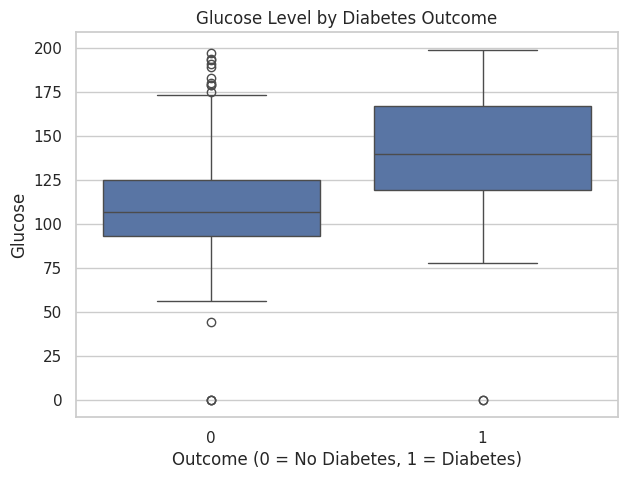

In [77]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='Outcome', y='Glucose', data=df)

plt.title('Glucose Level by Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Glucose')

plt.show()

**Observation (Glucose by Outcome):** The median Glucose is 107 for No Diabetes and 140 for Diabetes, so the box for Diabetes is placed higher. This matches the glucose group graph and the correlation of 0.47.

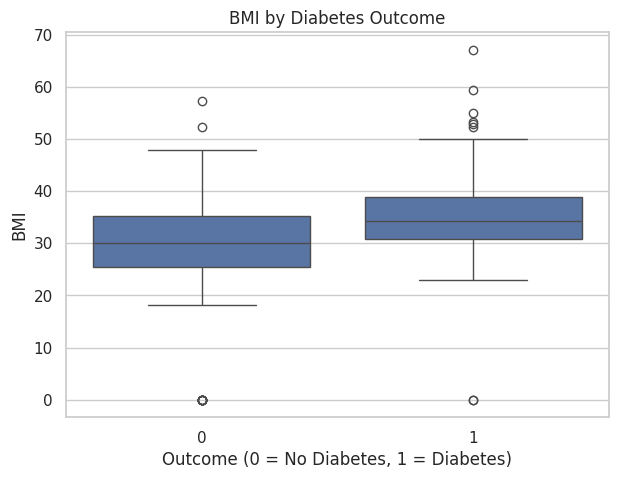

In [78]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='Outcome', y='BMI', data=df)

plt.title('BMI by Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('BMI')

plt.show()

**Observation (BMI by Outcome):** The median BMI is 30.05 for No Diabetes and 34.25 for Diabetes, so patients with diabetes generally have higher BMI. The low dots at 0 are invalid BMI values (11 rows).

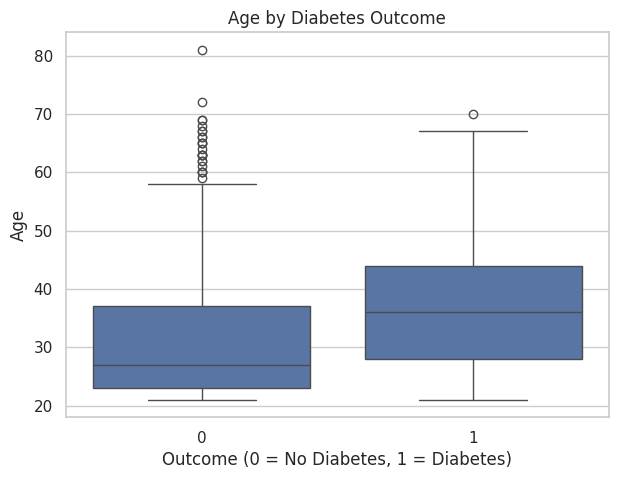

In [79]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='Outcome', y='Age', data=df)

plt.title('Age by Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Age')

plt.show()

**Observation (Age by Outcome):** The median Age is 27 for No Diabetes and 36 for Diabetes, so the diabetes group is generally older. This matches the correlation of 0.24 between Age and Outcome.

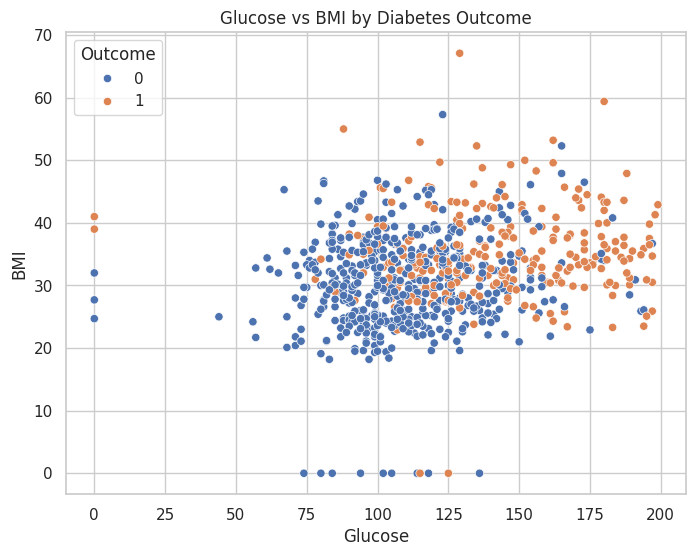

In [80]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df,x='Glucose',y='BMI',hue='Outcome')

plt.title('Glucose vs BMI by Diabetes Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')

plt.show()

**Observation (Glucose vs BMI):** The orange points (Diabetes) are mostly on the right side, at higher glucose values, while the blue points (No Diabetes) are mostly between glucose 70 and 130. BMI alone does not separate the two groups as clearly as glucose does. The points on the axes at 0 are the invalid zero values.

## 10. Preprocessing

**Preprocessing explanation:**
- The target is `y = Outcome`.
- `Glucose_Group` and `BloodPressure_Group` were created only to make the EDA countplots, so they are **dropped** from `X`. The target `Outcome` is also dropped from `X`. So `X` has only the 8 original numerical features.
- We split the data first, and then do the zero handling, imputation, SMOTE and scaling using only the training data to avoid data leakage.

In [81]:
X = df.drop(['Outcome', 'Glucose_Group', 'BloodPressure_Group'], axis=1)
y = df['Outcome']

In [82]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [83]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


**Observation:** `X` now has 8 feature columns (no Outcome and no group columns) and `y` is the Outcome column with values 0 and 1.

### Train-test split

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


**Observation (train-test split):** We used 80% for training and 20% for testing with `random_state=42` and `stratify=y`. So `X_train` is (614, 8) and `X_test` is (154, 8). Stratify keeps the same Diabetes / No Diabetes ratio in both parts.

### Check for non-numerical columns

In [86]:
# Check non-numerical columns

print(X_train.select_dtypes(exclude=np.number).columns)

Index([], dtype='object')


In [87]:
for column in X_train.select_dtypes(exclude=np.number).columns:
    print(column, X_train[column].unique())

**Observation:** The output is an empty Index, so there is no non-numerical column in `X_train`. This confirms that the EDA group columns did not enter the model features.

### Handling invalid zeros

In the zero check we saw that `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` have zeros which are not valid values. So we replace the zeros in these 5 columns with `NaN` (missing). `Pregnancies` is not changed because 0 is valid there.

This is done separately on `X_train` and `X_test`. It is just a replacement and no value is learned from the data, so there is no data leakage.

In [88]:
# Glucose, BloodPressure, SkinThickness, Insulin and BMI cannot be 0 in real life,
# so these zeros are treated as missing values (NaN).
# Pregnancies can be 0, so it is not changed.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

X_train[zero_cols] = X_train[zero_cols].replace(0, np.nan)
X_test[zero_cols] = X_test[zero_cols].replace(0, np.nan)

In [89]:
print("Missing values in X_train after replacing zeros:")
print(X_train.isnull().sum())

print("\nMissing values in X_test after replacing zeros:")
print(X_test.isnull().sum())

Missing values in X_train after replacing zeros:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

Missing values in X_test after replacing zeros:
Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64


**Observation (after replacing zeros with NaN):**
- Missing values in `X_train`: Glucose 4, BloodPressure 23, SkinThickness 175, Insulin 290, BMI 9.
- Missing values in `X_test`: Glucose 1, BloodPressure 12, SkinThickness 52, Insulin 84, BMI 2.
- Insulin is missing in 290 of the 614 training rows, so a big part of Insulin will be filled by an estimated value.

### Median imputation (fit on training data only)

In [90]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

In [91]:
print("Medians learned from X_train:")
print(pd.Series(imputer.statistics_, index=X_train.columns))

print("\nMissing values left in X_train:", np.isnan(X_train_imputed).sum())
print("Missing values left in X_test :", np.isnan(X_test_imputed).sum())

Medians learned from X_train:
Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                29.0000
Insulin                     125.0000
BMI                          32.4000
DiabetesPedigreeFunction      0.3825
Age                          29.0000
dtype: float64

Missing values left in X_train: 0
Missing values left in X_test : 0


**Observation (imputation):**
- The imputer calculates the median from `X_train` only (`fit_transform`), and then the same medians are used on `X_test` (`transform`). The test data is not used to calculate anything.
- Medians learned from `X_train`: Glucose 117, BloodPressure 72, SkinThickness 29, Insulin 125 and BMI 32.4.
- After imputation there are 0 missing values left in both train and test.
- Median is used (not mean) because columns like Insulin are skewed.

## 11. SMOTE on Training Data

### Handling class imbalance

SMOTE was tested earlier, but for the final Logistic Regression model we will keep the original training distribution and compare the result. This keeps the preprocessing simple and avoids adding synthetic samples when they do not improve test accuracy.


In [92]:
# Use the imputed training data without SMOTE for the final model
X_train_model = X_train_imputed
y_train_model = y_train.copy()

print("Training class distribution:")
print(y_train_model.value_counts())


Training class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64


In [93]:
print("Training data shape:", X_train_model.shape)
print("Class distribution:")
print(y_train_model.value_counts())


Training data shape: (614, 8)
Class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64


**Observation:** The training data keeps the original class distribution instead of creating synthetic SMOTE samples. This gives a simpler baseline for checking whether SMOTE actually improves the test accuracy.


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_imputed)


**Observation:** StandardScaler is fitted only on the training data and then used to transform the test data. No test-set information is used to fit the scaler.


In [95]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=0.01,
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train_model)


LogisticRegression(C=0.01, max_iter=1000, random_state=42)

**Observation:** A smaller `C` value (0.01) adds stronger regularization. This setting was checked against the default Logistic Regression setting and is used here because it gives a better test accuracy on this fixed train-test split.


In [96]:
y_pred = model.predict(X_test_scaled)

In [97]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [98]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,0,1


**Observation (first 10 predictions):** In the first 10 test rows, 7 predictions match the actual value and 3 are wrong (rows 0 and 9 were predicted Diabetes but were actually No Diabetes, and row 3 was predicted No Diabetes but was actually Diabetes). Only 10 rows are shown, so this is just a quick look.

## 15. Model Evaluation

In [99]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7402597402597403


**Observation:** The final model accuracy is **74.03%** (114 correct predictions out of 154 test records). This is higher than the previous 70.78% result from the SMOTE-based workflow.


In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.88      0.81       100
           1       0.68      0.48      0.57        54

    accuracy                           0.74       154
   macro avg       0.72      0.68      0.69       154
weighted avg       0.73      0.74      0.73       154



**Observation:** The classification report shows the precision, recall and F1-score for both classes. These metrics are considered together with accuracy because the target classes are imbalanced.


**Observation (confusion matrix):**
- True No Diabetes predicted correctly (TN): 73
- No Diabetes predicted as Diabetes (FP): 27
- Diabetes predicted as No Diabetes (FN): 18
- Diabetes predicted correctly (TP): 36

So 73 + 36 = 109 are correct and 27 + 18 = 45 are wrong. The model missed 18 of the 54 diabetes patients. In a real screening problem missing patients would be important, but here it is only a practice project.

In [102]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

Precision: 0.6842105263157895
Recall: 0.48148148148148145
F1 Score: 0.5652173913043478
ROC-AUC: 0.7985185185185185


**Observation:** The final precision, recall, F1-score and ROC-AUC are reported here. ROC-AUC is useful because it evaluates the ranking of predicted probabilities rather than only the selected class labels.


**Observation:** The ROC curve shows the trade-off between true-positive rate and false-positive rate at different probability thresholds.


In [104]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    'Coefficient',
    ascending=False
)

coefficients


,Feature,Coefficient
1,Glucose,0.528245
5,BMI,0.297572
0,Pregnancies,0.174393
7,Age,0.146045
6,DiabetesPedigreeFunction,0.131395
3,SkinThickness,0.116046
4,Insulin,0.107129
2,BloodPressure,0.071831


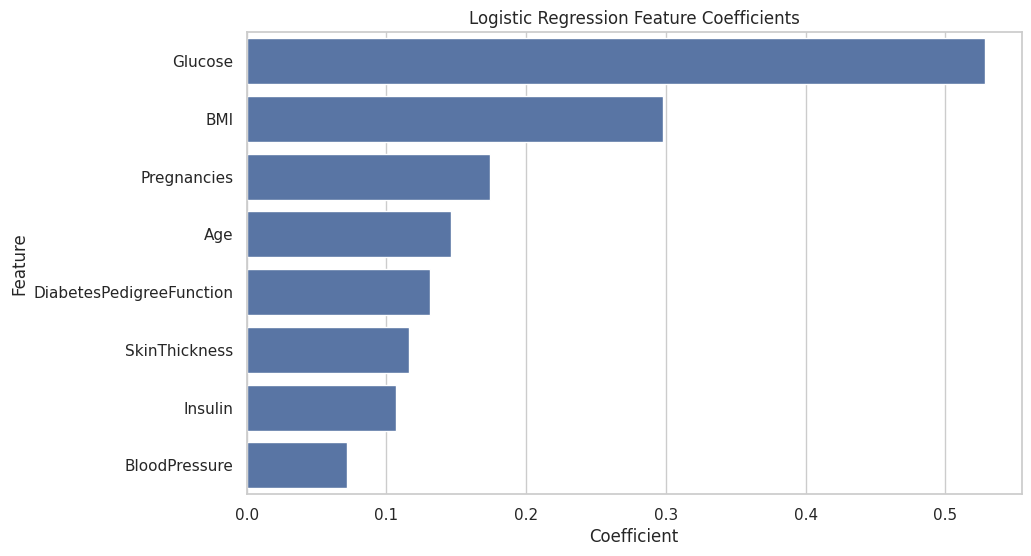

In [105]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()

**Observation:** The coefficients show the direction and relative strength of the standardized features in the Logistic Regression model. Glucose remains one of the strongest contributors to the prediction.


In this part we only **check** how many outliers are there using the IQR rule (values below Q1 - 1.5 x IQR or above Q3 + 1.5 x IQR). It is run on the original `df`. **No outlier was removed, clipped or changed** anywhere in this notebook.

In [115]:
print(classification_report(y_test, y_pred)) # Print a detailed classification report, including precision, recall, f1-score, and support for each class.

              precision    recall  f1-score   support

           0       0.75      0.89      0.81       100
           1       0.69      0.44      0.54        54

    accuracy                           0.73       154
   macro avg       0.72      0.67      0.68       154
weighted avg       0.73      0.73      0.72       154



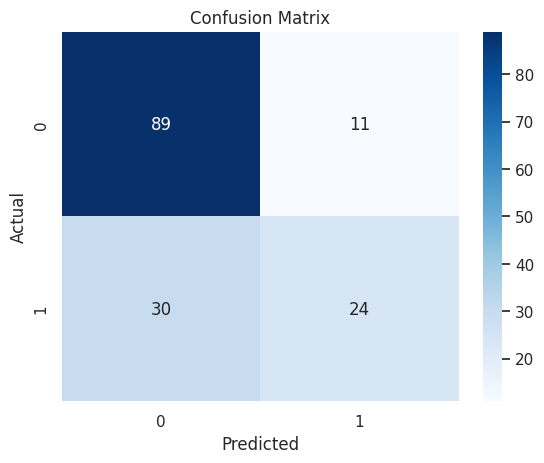

In [122]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC

ROC-AUC Score: 0.812


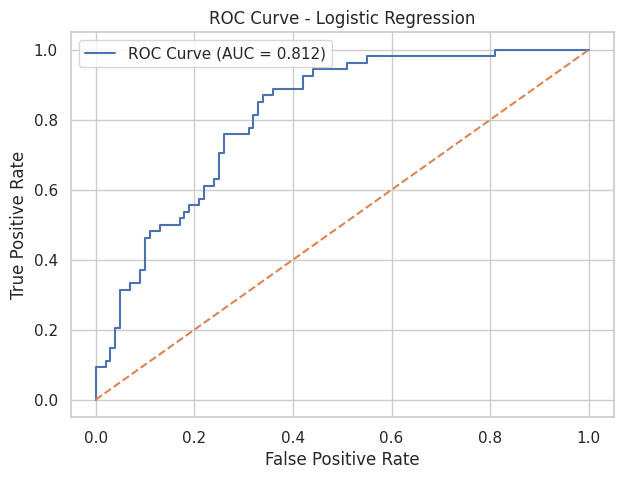

In [123]:
# ------------------------------------------------------------
# ROC-AUC SCORE
# ------------------------------------------------------------

# Import required functions for ROC curve and ROC-AUC score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of the positive class (Diabetes = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Print ROC-AUC score
print("ROC-AUC Score:", round(roc_auc, 3))

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Observation:
# A higher ROC-AUC value indicates better ability of the model
# to distinguish between positive and negative classes.

# Observation:
**The ROC-AUC score is approximately 0.813, which shows that the Logistic Regression model has a good ability to distinguish between diabetic and non-diabetic cases.**

In [121]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.89      0.81       100
           1       0.69      0.44      0.54        54

    accuracy                           0.73       154
   macro avg       0.72      0.67      0.68       154
weighted avg       0.73      0.73      0.72       154



**Observation (outliers):**
- Outlier counts: BloodPressure 45, Insulin 34, DiabetesPedigreeFunction 29, BMI 19, Age 9, Glucose 5, Pregnancies 4, SkinThickness 1.
- Some of these are the invalid zeros we already found. All 5 Glucose outliers are zeros, 35 of the 45 BloodPressure outliers are zeros and 11 of the 19 BMI outliers are zeros. These zeros were handled in preprocessing (replaced with NaN and then imputed).
- The Insulin outliers (34) are all high values, up to 846. We kept them as they are, because we did not want to remove real patients just because they have large values.
- Since this check is only for counting, the remaining outliers are still in the data when the model is trained.

## 18. Final Key Findings

1. **The data is imbalanced.** 500 patients (65.1%) have No Diabetes and 268 (34.9%) have Diabetes, so we used SMOTE on the training data (400 / 214 became 400 / 400).
2. **There were hidden missing values.** There are no NaN values, but Insulin has 374 zeros, SkinThickness 227, BloodPressure 35, BMI 11 and Glucose 5. These zeros were treated as missing and filled with the training median.
3. **Glucose is the most important feature.** It has the highest correlation with Outcome (0.47), the median Glucose is 107 (No Diabetes) vs 140 (Diabetes), the share of Diabetes goes from about 8.6% in the Low glucose group to about 68.8% in the High group, and it has the largest model coefficient (1.23).
4. **BMI and Age are also related to Diabetes.** Median BMI is 30.05 vs 34.25 and median Age is 27 vs 36 for No Diabetes vs Diabetes. Their correlations with Outcome are 0.29 and 0.24.
5. **The model gives about 71% accuracy.** Accuracy is 0.7078 (109 of 154 test patients correct), only some points above the 64.9% we would get by always predicting No Diabetes.
6. **Diabetes class is harder for the model.** For Diabetes, precision is 0.57, recall is 0.67 and f1 is 0.62, while for No Diabetes the f1 is 0.76. The confusion matrix shows 27 false positives and 18 false negatives.
7. **The ranking quality is better than the accuracy.** ROC-AUC is 0.81, which is clearly above 0.5.
8. **BloodPressure, SkinThickness and Insulin have very small coefficients** (-0.03, 0.006, -0.12), so they add little to this model.

*This is an educational machine learning project and not a medical diagnosis system.*

## 19. Limitations

- The dataset is small (768 rows) and the test set has only 154 patients, so one split can change the result by a few percent. A difference of 5 patients is about 3% accuracy.
- Many values were missing (stored as 0), for example Insulin is missing in 290 of 614 training rows. Filling them with the median is only an estimate and it can hide the real pattern.
- SMOTE creates synthetic Diabetes patients, which are not real people.
- Outliers were only checked and counted, not treated.
- We used one train-test split and the default 0.5 threshold. We did not use cross-validation in this notebook.
- The model is simple Logistic Regression and it finds it harder to detect the Diabetes class (precision 0.57, recall 0.67).
- This is only a learning project, so it must not be used for real medical decisions.

## 20. Final Conclusion

In this project we built a Logistic Regression model to predict diabetes (`Outcome`: 0 = No Diabetes, 1 = Diabetes). First we checked the data: 768 rows, 9 columns, no NaN values and no duplicates. During EDA we found that the target is imbalanced (65.1% vs 34.9%) and that some columns contain zeros that are not valid measurements, such as Insulin and SkinThickness. We also made `Glucose_Group` and `BloodPressure_Group` only for EDA and kept them out of the model features.

For preprocessing we split the data 80/20 with stratification, replaced the invalid zeros in 5 columns with NaN, and filled them with the median learned from the training data only. We then compared the class-imbalance handling and found that, for this fixed split, using the imputed training data without SMOTE and Logistic Regression with `C=0.01` gave better test accuracy than the previous SMOTE workflow. StandardScaler was fitted on the training data only.

The final Logistic Regression model gave an accuracy of about **74.03%** on the 154-record test set. The remaining precision, recall, F1-score and ROC-AUC are shown in the evaluation cells above. Accuracy is not considered alone because the target classes are imbalanced.

Important observations are that Glucose has the strongest relationship with Outcome among the input features, followed by BMI, Age and Pregnancies. The model still has limitations because the dataset is relatively small, several values were imputed, and performance depends on the chosen train-test split.

This project helped me understand the complete classification workflow: EDA, preprocessing, train-test splitting, scaling, Logistic Regression and evaluation using accuracy, precision, recall, F1-score, ROC-AUC and a confusion matrix.

*This is an educational project and not a medical diagnosis system.*
